In [2]:
import torch
from torch.utils.data import Dataset
from glob import glob
from PIL import Image
from pathlib import Path

%load_ext autoreload
%autoreload 2


In [3]:
image_dir = './cvat_annotations/cvat_test/images/'
image_files = [Path(f) for f in glob(f'{image_dir}*.png')]
print(image_files)

[PosixPath('cvat_annotations/cvat_test/images/20211014T130100Z_t741-2444_a60.png'), PosixPath('cvat_annotations/cvat_test/images/20211014T130100Z_t741-2444_a786.png'), PosixPath('cvat_annotations/cvat_test/images/20211014T123100Z_t120-994_a562.png'), PosixPath('cvat_annotations/cvat_test/images/20211014T130100Z_t741-2444_a142.png'), PosixPath('cvat_annotations/cvat_test/images/20211014T130100Z_t741-2444_a817.png'), PosixPath('cvat_annotations/cvat_test/images/20211014T123100Z_t120-994_a951.png'), PosixPath('cvat_annotations/cvat_test/images/20211014T130100Z_t741-2444_a140.png'), PosixPath('cvat_annotations/cvat_test/images/20211014T123100Z_t120-994_a560.png'), PosixPath('cvat_annotations/cvat_test/images/20211014T130100Z_t741-2444_a785.png'), PosixPath('cvat_annotations/cvat_test/images/20211014T123100Z_t120-994_a158.png'), PosixPath('cvat_annotations/cvat_test/images/20211028T153100Z_t2361-3093_a958.png'), PosixPath('cvat_annotations/cvat_test/images/20211014T130100Z_t741-2444_a784.pn

In [3]:
image_files[0].name

'20211014T130100Z_t741-2444_a60.png'

In [4]:
Image(image_files[0])

TypeError: 'module' object is not callable

In [4]:
import numpy as np
import cv2
import xml.etree.ElementTree as ET
from typing import List, Tuple, Dict
import distinctipy
import sys
def parse_polygons_from_xml(xml_file: str) -> Dict[str, Dict]:
    """Parse polygon points from XML file."""
    tree = ET.parse(xml_file)
    root = tree.getroot()
    
    image_polygons = {}
    
    for image in root.findall('.//image'):
        image_name = image.get('name')
        width = int(image.get('width'))
        height = int(image.get('height'))
        
        polygons = []
        for polygon in image.findall('.//polygon'):
            points_str = polygon.get('points')
            points = [tuple(map(float, point.split(','))) 
                     for point in points_str.split(';')]
            polygons.append(points)
            
        if polygons:
            image_polygons[image_name] = {
                'polygons': polygons,
                'width': width,
                'height': height
            }
    
    return image_polygons


In [6]:
from cvat_annotations.cvat_xml import parse_polygons_from_xml

In [15]:
sum = 0
numel = 0
var = 0
for file in poly_labels.keys():
    img = np.array(Image.open(f'cvat_annotations/cvat_test//images/{file}'))
    sum += img.sum()
    numel += img.shape[0] * img.shape[1]
    var += ((img - img.mean())**2).sum()
print('mean', sum/numel)
print('std', np.sqrt(var / numel))

mean 123.15394544270833
std 50.414253020098215


In [26]:
from dataset import DunexDataset
ds = DunexDataset('cvat_annotations/cvat_test/images', 'cvat_annotations/cvat_test/annotations_poly.xml')
img, mask = ds[0]

torch.Size([1, 128, 128]) torch.Size([1, 128, 128])


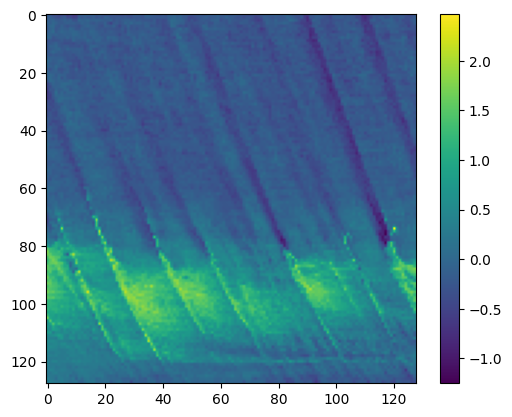

In [20]:
plt.imshow(np.array(img[0]))
plt.colorbar()
# plt.imshow(mask[0], cmap='hot', alpha=0.5)


In [23]:
from network import ResNetUNet
import torch
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = ResNetUNet(n_class=1)
model = model.to(device)


/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
from dataset import DunexDataset
ds = DunexDataset('cvat_annotations/cvat_test/images', 'cvat_annotations/cvat_test/annotations_poly.xml', patch_size=(128, 128))
img, mask = ds[0]
pred = model(img.unsqueeze(0).to(device)).cpu().detach().numpy()

NameError: name 'model' is not defined

In [ ]:
from loss import *


In [24]:
from collections import defaultdict
import torch.nn.functional as F
# from loss import dice_loss

import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
from tqdm import tqdm

def print_metrics(metrics, epoch_samples, phase):
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))

    print("{}: {}".format(phase, ", ".join(outputs)))

def train_model(model, optimizer, scheduler, num_epochs=25):
    l = []
    validation_metrics = defaultdict(list)
    train_metrics = defaultdict(list)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        since = time.time()

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                scheduler.step()
                for param_group in optimizer.param_groups:
                    print("LR", param_group['lr'])

                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            metrics = defaultdict(float)
            epoch_samples = 0

            for inputs, labels in (dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                
                    loss = calc_loss(outputs, labels, metrics, epoch)


                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                    
                # statistics
                epoch_samples += inputs.size(0)
            
            if phase == 'train':
                train_metrics['boundary_loss'].append(metrics['boundary']/epoch_samples)
                train_metrics['focal'].append(metrics['focal']/epoch_samples)
                train_metrics['dice'].append(metrics['dice']/epoch_samples)
                train_metrics['disc'].append(metrics['disc']/epoch_samples)
                train_metrics['loss'].append(loss.detach().cpu())
                
            if phase == 'val':
                validation_metrics['boundary_loss'].append(metrics['boundary']/epoch_samples)
                validation_metrics['focal'].append(metrics['focal']/epoch_samples)
                validation_metrics['dice'].append(metrics['dice']/epoch_samples)
                validation_metrics['disc'].append(metrics['disc']/epoch_samples)
                validation_metrics['loss'].append(loss.detach().cpu())


            print_metrics(metrics, epoch_samples, phase)
            epoch_loss = metrics['loss'] / epoch_samples
            
            # deep copy the model
            if phase == 'val' and epoch_loss < best_loss:
                print("saving best model")
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())

        if phase == 'val':
            l.append(epoch_loss)

        time_elapsed = time.time() - since
        print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    print('Best val loss: {:4f}'.format(best_loss))


    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, l, train_metrics, validation_metrics

[autoreload of loss failed: Traceback (most recent call last):
  File "/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/Users/mleclair/.pyenv/versions/3.12.1/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 990, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1128, in get_code
  File "<frozen importlib._bootstrap_external>", line 1058, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/Users/mleclair/Dropbox/phd/code/dunex/video/timestack_breakers_unet/loss.p

Epoch 0/199
----------
LR 0.0005323741007194245
train: focal: 0.055400, dice: 0.938864, loss: 0.497132, boundary: 0.000000, disc: 0.000000
val: focal: 0.048544, dice: 0.933741, loss: 0.491143, boundary: 0.000000, disc: 0.000000
saving best model
0m 10s
Epoch 1/199
----------
LR 0.0005647482014388489
train: focal: 0.031283, dice: 0.934677, loss: 0.482980, boundary: 0.000000, disc: 0.000000
val: focal: 0.021179, dice: 0.934515, loss: 0.477847, boundary: 0.000000, disc: 0.000000
saving best model
0m 6s
Epoch 2/199
----------
LR 0.0005971223021582734
train: focal: 0.022402, dice: 0.913667, loss: 0.468035, boundary: 0.000000, disc: 0.000000
val: focal: 0.014220, dice: 0.902450, loss: 0.458335, boundary: 0.000000, disc: 0.000000
saving best model
0m 6s
Epoch 3/199
----------
LR 0.0006294964028776979
train: focal: 0.016987, dice: 0.847315, loss: 0.432151, boundary: 0.000000, disc: 0.000000
val: focal: 0.022700, dice: 0.802490, loss: 0.412595, boundary: 0.000000, disc: 0.000000
saving best mod

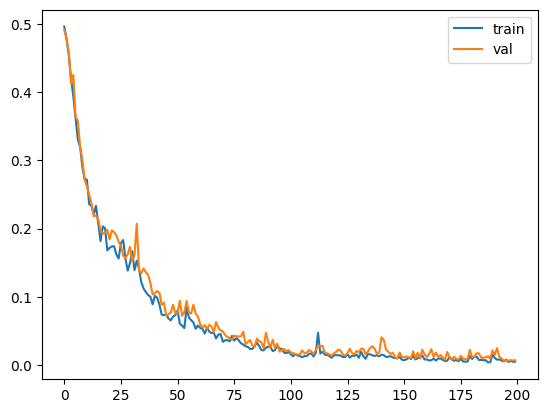

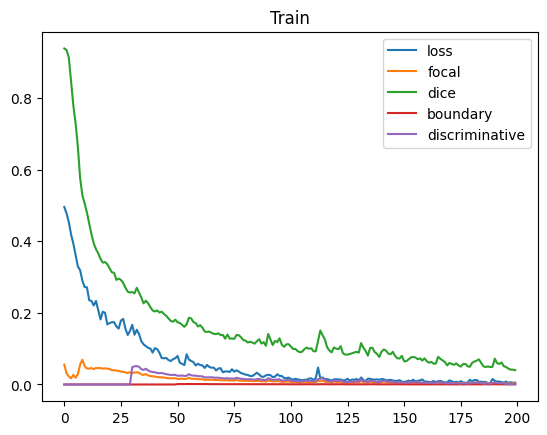

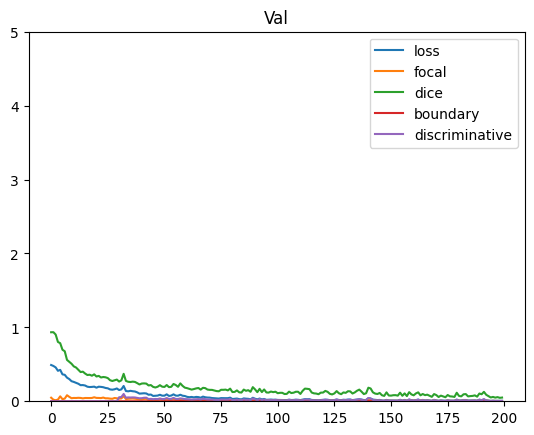

In [131]:
from loss import *
from torch.utils.data import Dataset, DataLoader
from network import *
ds = DunexDataset('cvat_annotations/cvat_test/images', 'cvat_annotations/cvat_test/annotations_poly.xml', patch_size=(128, 128))
train_split = 0.75
train, val = torch.utils.data.random_split(ds, [400, 104])
batch_size = 64
dataloaders = {
    'train': DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=0),
    'val': DataLoader(val, batch_size=batch_size, shuffle=True, num_workers=0)
}

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

num_class = 1
model = ResNetUNet(num_class).to(device)

# freeze backbone layers
#for l in model.base_layers:
#    for param in l.parameters():
#        param.requires_grad = False

optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-2)
# scheduler = lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, 
#                                          patience=20, min_lr=1e-6)


# exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=30, gamma=0.1)

# optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
from torch.optim.lr_scheduler import OneCycleLR
scheduler = OneCycleLR(optimizer_ft, 
                       max_lr=5e-3,  # Increased from 1e-3
                       epochs=100,    # Train longer
                       steps_per_epoch=len(dataloaders['train']),
                      div_factor=10, # Smaller div_factor for higher starting LR
                      final_div_factor=1e2, # Less aggressive final LR reduction
                      pct_start=0.2,  # Shorter warmup
                      anneal_strategy='linear') # Linear annealing


model, loss, train_metrics, val_metrics= train_model(model, optimizer_ft, scheduler, num_epochs=200)

plt.figure()
plt.plot(train_metrics['loss'], label='train')
plt.plot(val_metrics['loss'], label='val')
plt.legend()

plt.figure()
plt.plot(train_metrics['loss'], label='loss')
plt.plot(train_metrics['focal'], label='focal')
plt.plot(train_metrics['dice'], label='dice')
plt.plot(train_metrics['boundary_loss'], label='boundary')
plt.plot(train_metrics['disc'], label='discriminative')
plt.title('Train')
plt.legend()

plt.figure()
plt.plot(val_metrics['loss'], label='loss')
plt.plot(val_metrics['focal'], label='focal')
plt.plot(val_metrics['dice'], label='dice')
plt.plot(val_metrics['boundary_loss'], label='boundary')
plt.plot(val_metrics['disc'], label='discriminative')
plt.title('Val')
plt.legend()

Text(0.5, 1.0, 'Error')

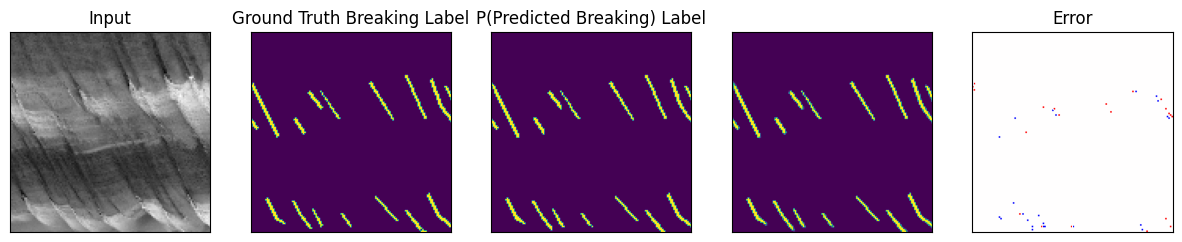

In [231]:
from dataset import DunexDataset
# ds = DunexDataset('cvat_annotations/cvat_test/images', 'cvat_annotations/cvat_test/annotations_poly.xml', patch_size=(128, 128))
img, mask = dataloaders['train'].dataset[1]
# img, mask = dataloaders['val'].dataset[0]
pred = F.sigmoid(model(img.unsqueeze(0).to(device))).cpu().detach().numpy()

fig, axs = plt.subplots(1, 5, figsize=(15, 5))

# Adjust the subplot layout to make room for colorbar
plt.subplots_adjust()  # Increase spacing between subplots

# Plot images
axs[1].imshow(mask[0])
axs[0].imshow(img[0], cmap='gray')
axs[2].imshow(pred.squeeze() > 0.5, cmap='viridis')
im = axs[3].imshow(pred.squeeze(), cmap='viridis', vmax=1, vmin=0)
diff = axs[4].imshow(mask[0] - (pred.squeeze() > 0.5), cmap='bwr', vmin=-1, vmax=1)

# Make all plots have same aspect ratio and remove ticks
for ax in axs:
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

# plt.colorbar(im, ax=axs[2])

# Add titles
axs[0].set_title("Input")
axs[1].set_title('Ground Truth Breaking Label')
axs[2].set_title('P(Predicted Breaking) Label')
axs[4].set_title('Error')

# Get the position info of the third subplot
# pos = axs[2].get_position()
# # Add colorbar
# cb_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.01, pos.height])
# fig.colorbar(im, cax=cb_ax)

# pos = axs[3].get_position()
# # Add colorbar
# cb_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.01, pos.height])
# fig.colorbar(diff, cax=cb_ax)

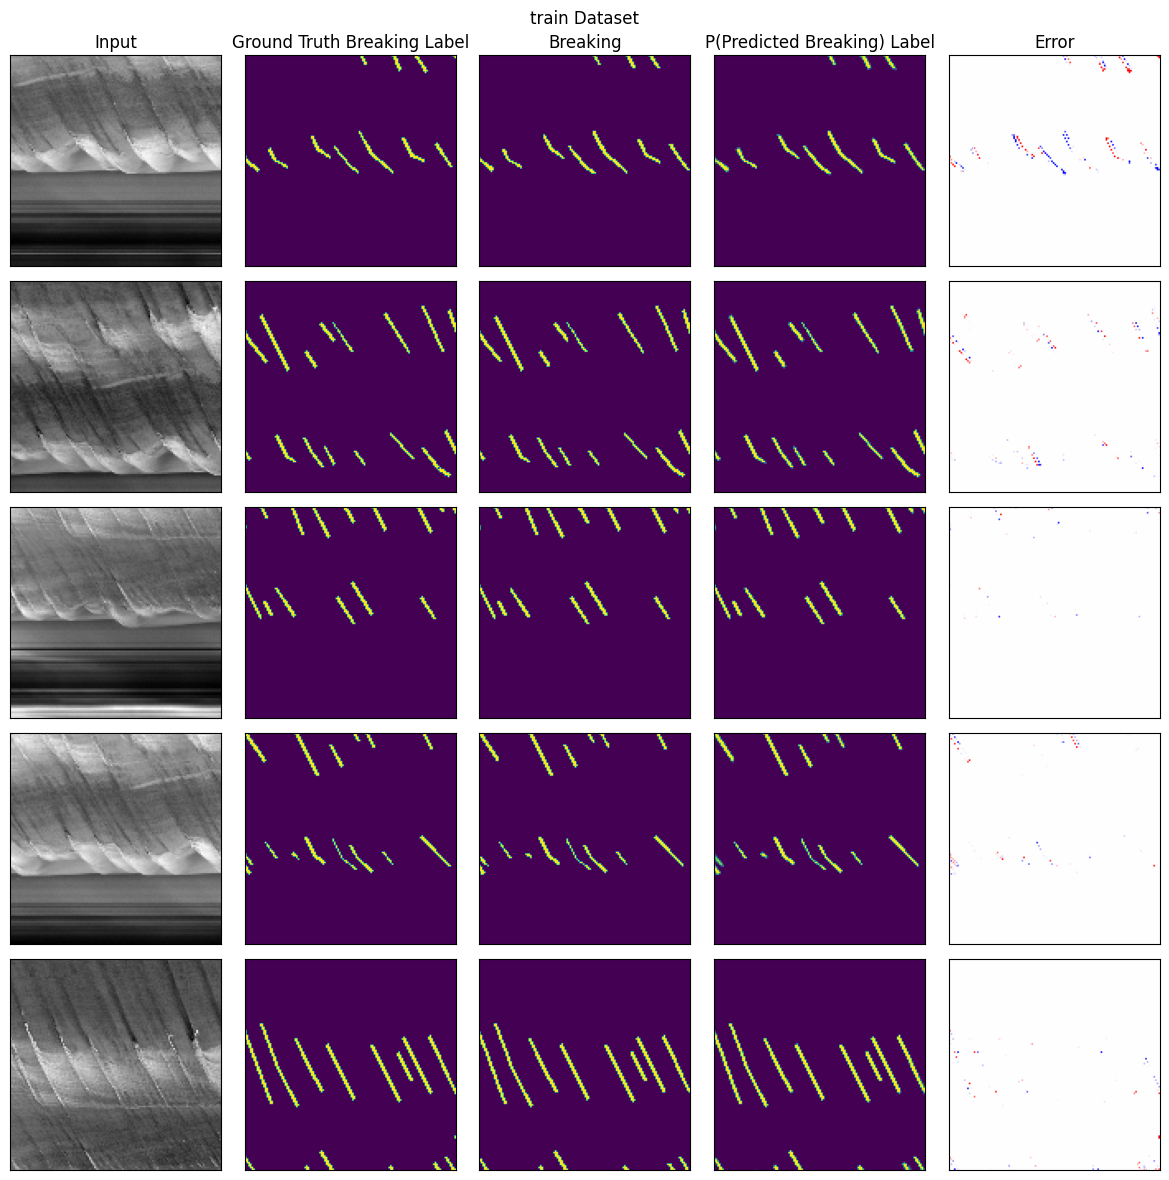

In [232]:
fig, axs = plt.subplots(5, 5, figsize=(12, 12))
plt.subplots_adjust(hspace=0.3)  # Add space between rows
d='train'
# Get predictions for multiple examples
for idx in range(5):
    img, mask = dataloaders[d].dataset[idx]
    pred = F.sigmoid(model(img.unsqueeze(0).to(device))).cpu().detach().numpy()
    
    # Plot images for this example
    axs[idx, 0].imshow(img[0], cmap='gray')
    axs[idx, 1].imshow(mask[0])
    im = axs[idx, 2].imshow(pred.squeeze()>0.5, cmap='viridis', vmax=1, vmin=0)
    im = axs[idx, 3].imshow(pred.squeeze(), cmap='viridis', vmax=1, vmin=0)
    diff = axs[idx, 4].imshow(mask[0] - pred.squeeze(), cmap='bwr', vmin=-1, vmax=1)
    
    # Make all plots have same aspect ratio and remove ticks
    for ax in axs[idx]:
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
    # Add row titles only to the first column
    if idx == 0:
        axs[idx, 0].set_title("Input")
        axs[idx, 1].set_title('Ground Truth Breaking Label')
        axs[idx, 2].set_title('Breaking')
        axs[idx, 3].set_title('P(Predicted Breaking) Label')
        axs[idx, 4].set_title('Error')
# Add colorbars for prediction and error
# for idx in range(4):
#     # Colorbar for prediction
#     pos = axs[idx, 2].get_position()
#     cb_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.01, pos.height])
#     plt.colorbar(im, cax=cb_ax)
    
#     # Colorbar for error
#     pos = axs[idx, 3].get_position()
#     cb_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.01, pos.height])
#     plt.colorbar(diff, cax=cb_ax)
fig.suptitle(f'{d} Dataset')
plt.tight_layout()
plt.show()


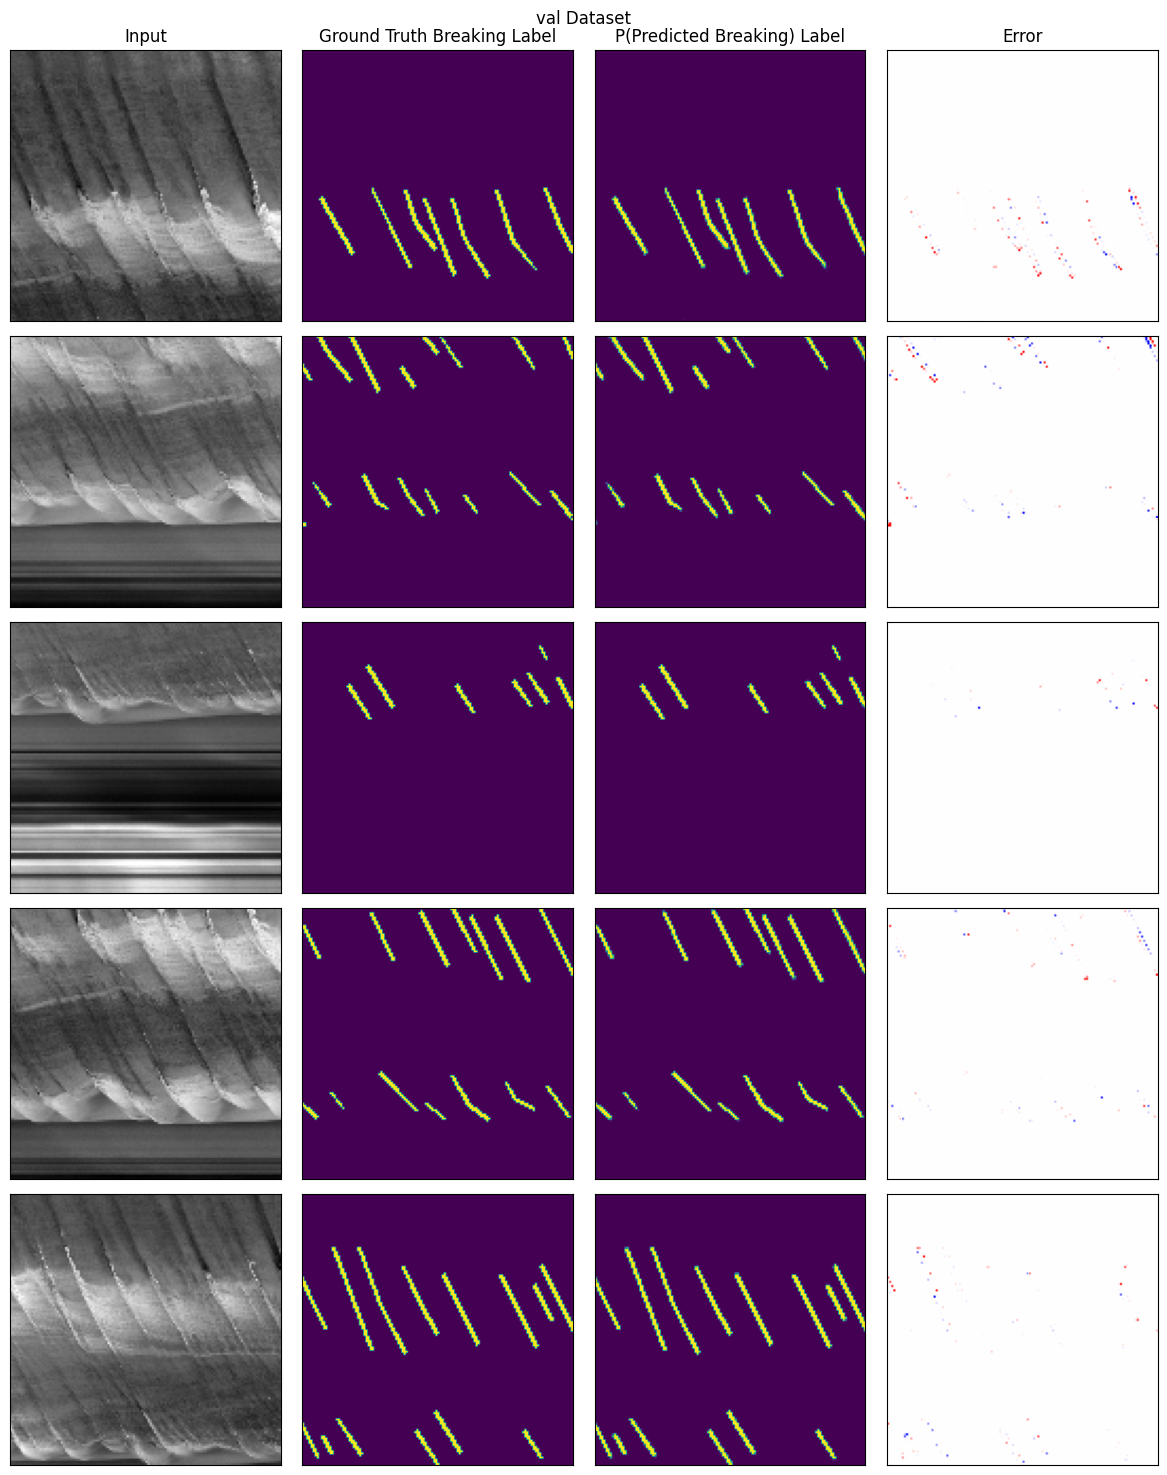

In [147]:
fig, axs = plt.subplots(5, 4, figsize=(12, 15))
plt.subplots_adjust(hspace=0.3)  # Add space between rows
ds='val'
# Get predictions for multiple examples
for idx in range(5):
    img, mask = dataloaders[d].dataset[idx]
    pred = F.sigmoid(model(img.unsqueeze(0).to(device))).cpu().detach().numpy()
    
    # Plot images for this example
    axs[idx, 0].imshow(img[0], cmap='gray')
    axs[idx, 1].imshow(mask[0])
    im = axs[idx, 2].imshow(pred.squeeze(), cmap='viridis', vmax=1, vmin=0)
    diff = axs[idx, 3].imshow(mask[0] - pred.squeeze(), cmap='bwr', vmin=-1, vmax=1)
    
    # Make all plots have same aspect ratio and remove ticks
    for ax in axs[idx]:
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
    # Add row titles only to the first column
    if idx == 0:
        axs[idx, 0].set_title("Input")
        axs[idx, 1].set_title('Ground Truth Breaking Label')
        axs[idx, 2].set_title('P(Predicted Breaking) Label')
        axs[idx, 3].set_title('Error')
# Add colorbars for prediction and error
# for idx in range(4):
#     # Colorbar for prediction
#     pos = axs[idx, 2].get_position()
#     cb_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.01, pos.height])
#     plt.colorbar(im, cax=cb_ax)
    
#     # Colorbar for error
#     pos = axs[idx, 3].get_position()
#     cb_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.01, pos.height])
#     plt.colorbar(diff, cax=cb_ax)
fig.suptitle(f'{ds} Dataset')
plt.tight_layout()
plt.show()


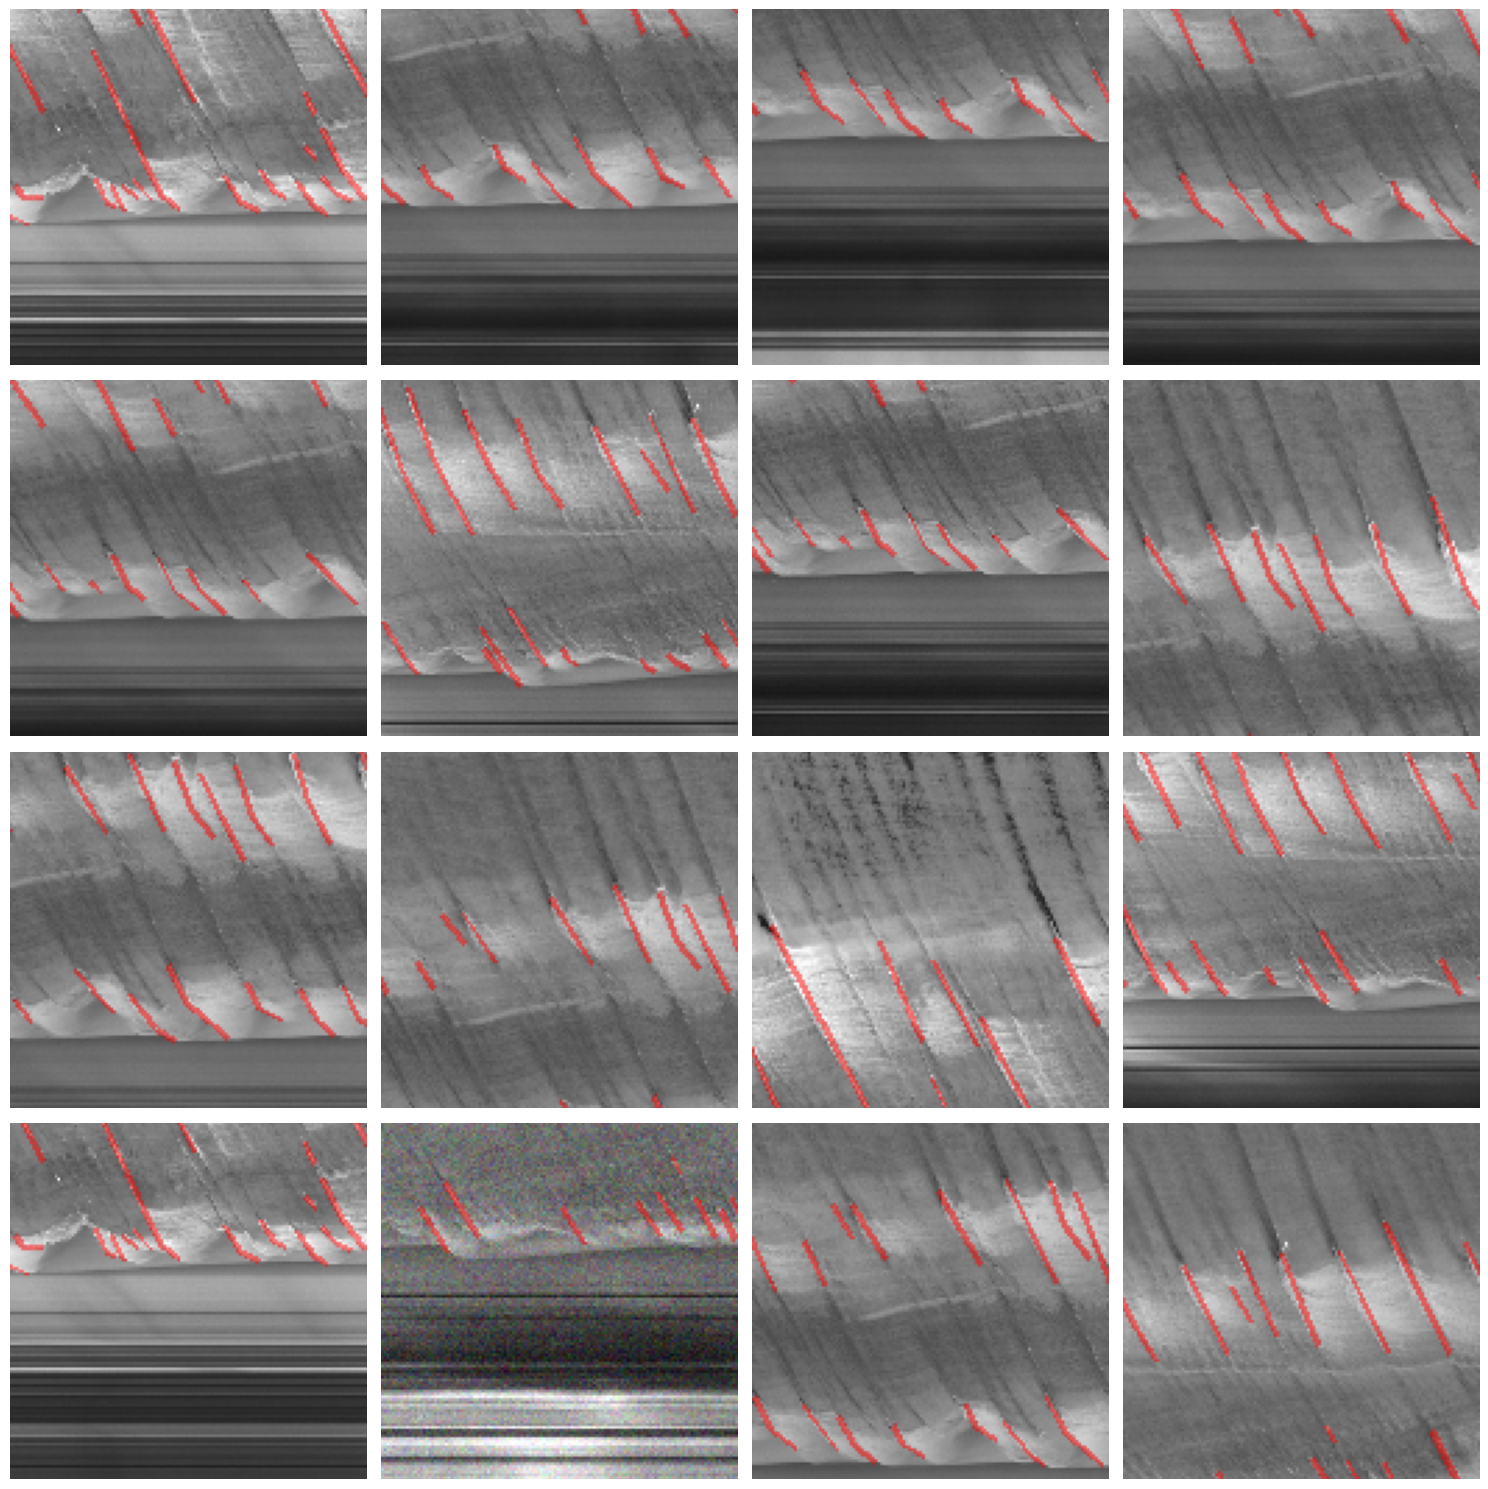

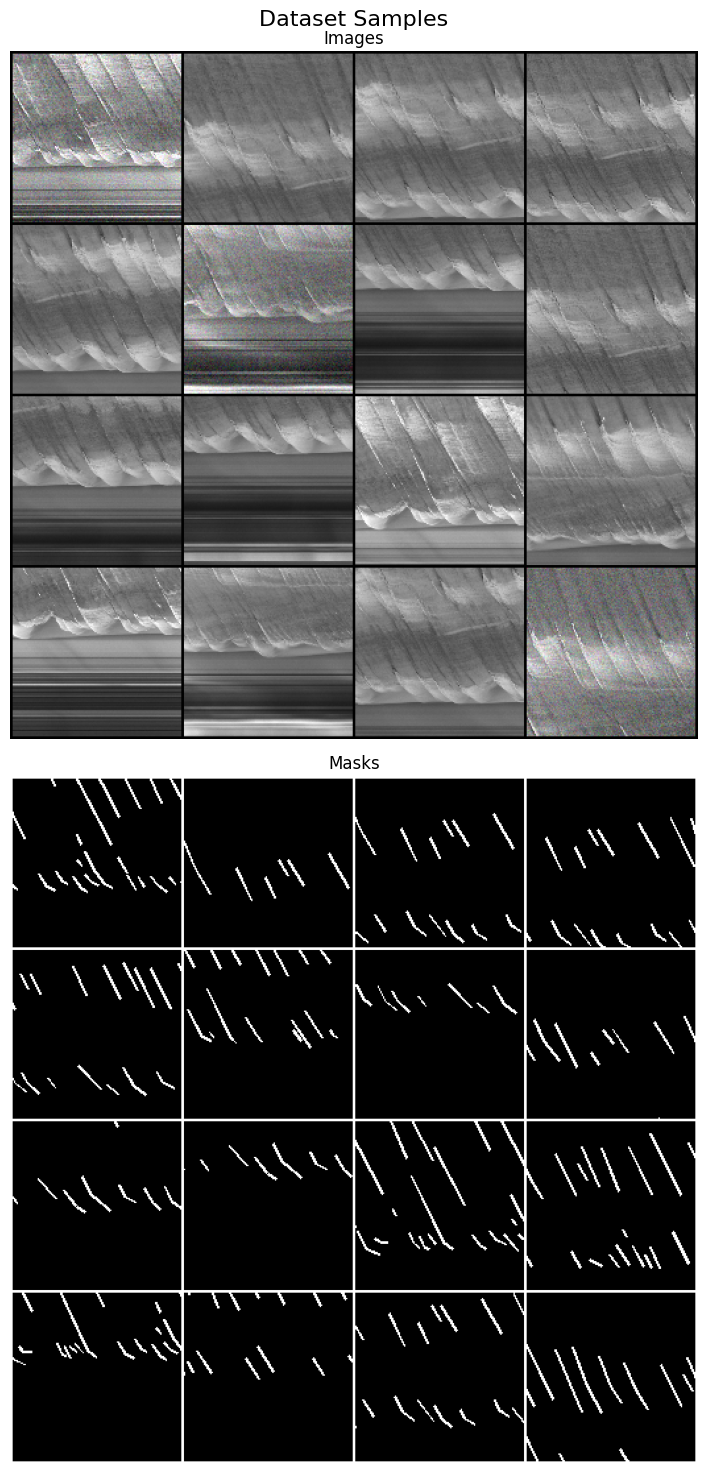

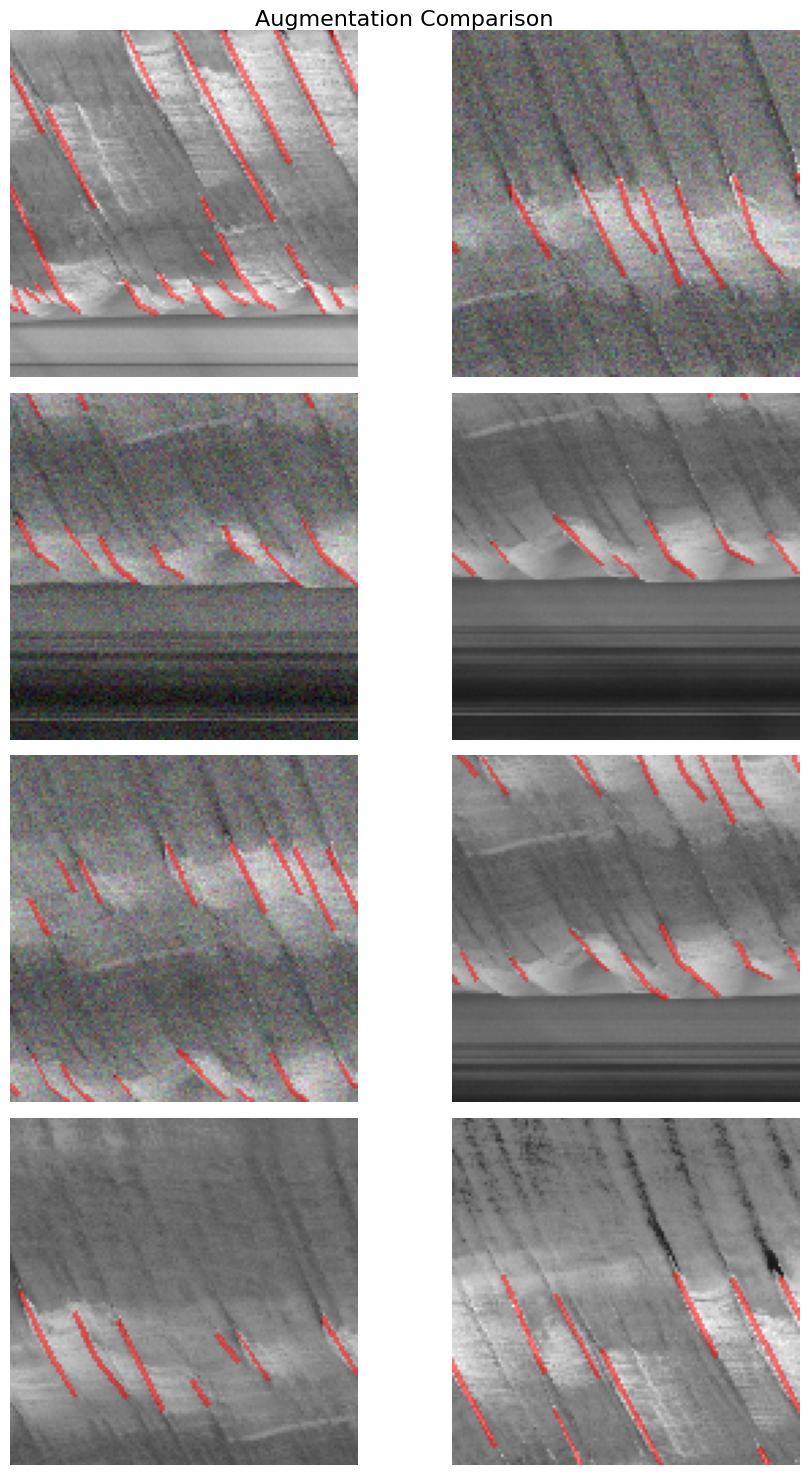

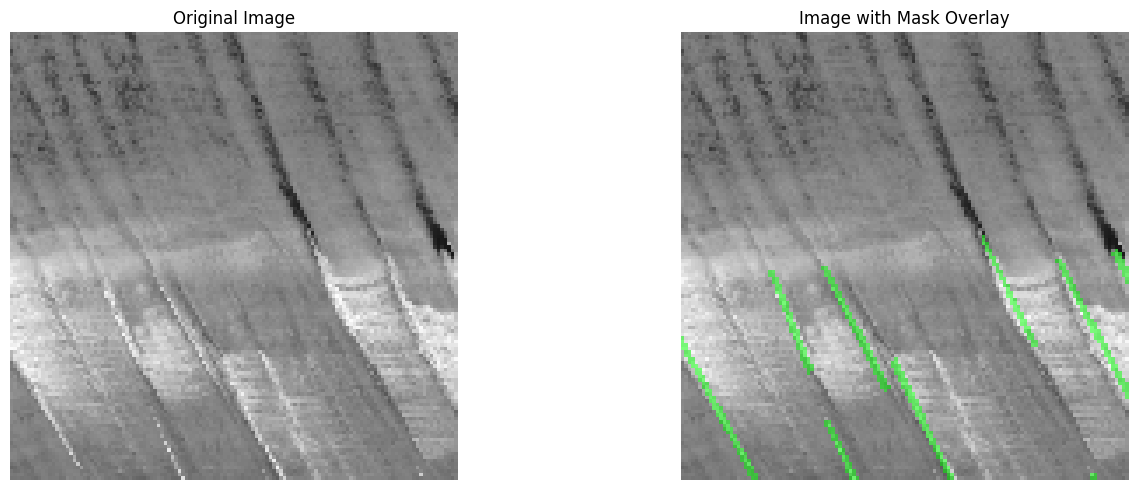

In [139]:
plot_dataset_grid(dataloaders['val'].dataset, num_images=16, overlay=True, mask_color='red')

# Plot grid with separate masks
plot_dataset_grid(dataloaders['val'].dataset, num_images=16, overlay=False)

# Compare augmentations with overlay
plot_augmentation_comparison(dataloaders['val'].dataset, num_images=4, overlay=True, mask_color=(1,0,0))  # RGB tuple for red

# Plot single sample with overlay
image, mask = dataloaders['val'].dataset[0]
plot_single_sample(image, mask, overlay=True, mask_color='green')


3.072gb allocated


Building Timestack: 100%|██████████| 3840/3840 [00:04<00:00, 831.51it/s]


(0.0, 1000.0)

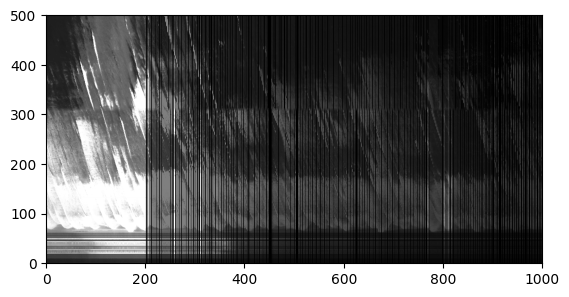

In [516]:
from predict import *
plt.rcParams['image.origin'] = 'lower'  # Set default origin to lower
patch = ts[100:100+128, 800, 100:100+128].T
pred = predict_patch(model, patch, device=device)


In [519]:
if len(img.shape) == 2:
    img = (img - img.mean()) / img.std()  # Normalize if needed

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# Get prediction
breakers = np.zeros_like(ts, dtype=float)
for i in tqdm(range(1600)):
    b = predict_large_image(model, ts[2000:3000, i, :].T/255.0, patch_size=128, overlap=32, batch_size=4, device=device).T
    # plt.imshow(b)
    # plt.show()
    # print(b.dtype)
    # print(breakers[2000:2300, i, :].dtype)
    breakers[2000:3000, i, :] = b
breakers = breakers[2000:3000]

  0%|          | 0/1600 [00:00<?, ?it/s]

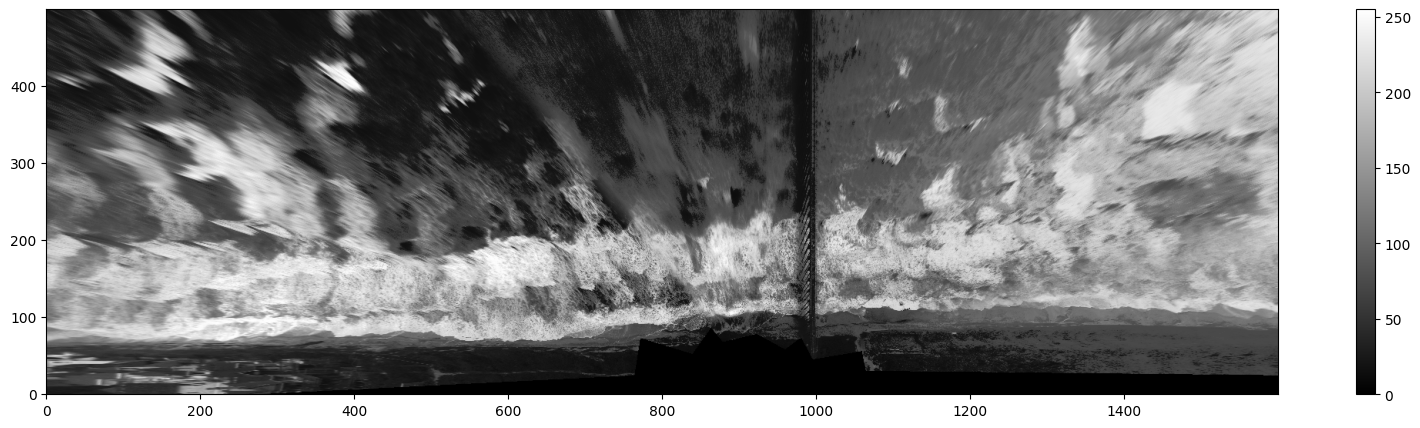

In [525]:
plt.figure(figsize=(20, 5))
plt.imshow(ts[2000].T, cmap='gray')
plt.colorbar()

Text(0.5, 1.0, 'Breakers/sec')

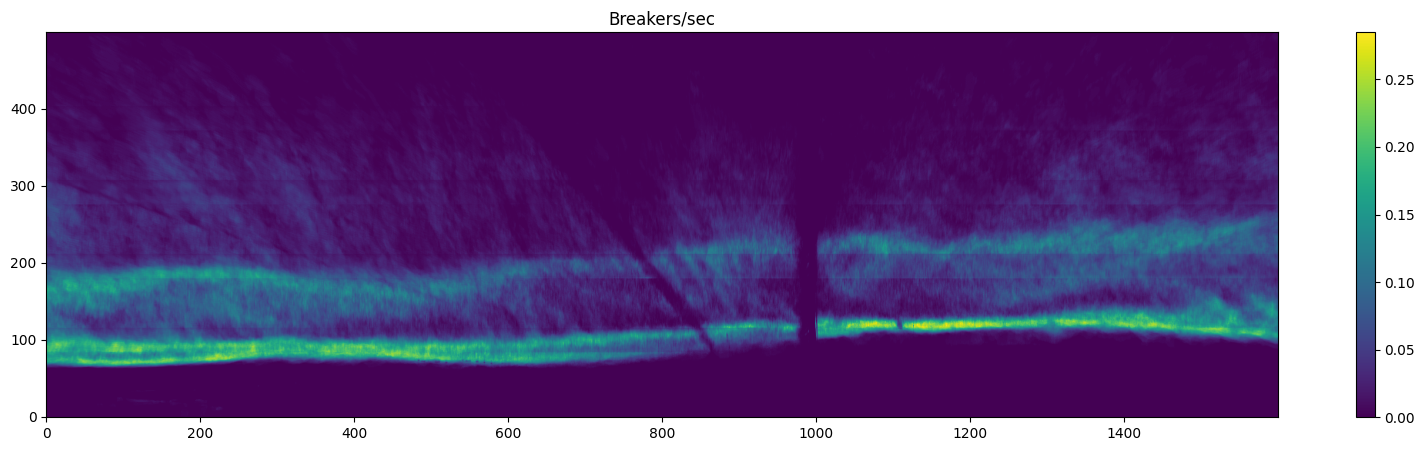

In [522]:
plt.figure(figsize=(20, 5))
plt.imshow(breakers.sum(0).T/1000*2)
plt.colorbar()
plt.title(f'Breakers/sec')

  0%|          | 0/1000 [00:00<?, ?it/s]

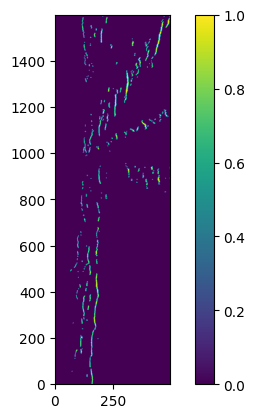

In [ ]:
from scipy.ndimage import label


filtered_breakers = np.zeros_like(breakers)
for i in tqdm(range(len(breakers))):
    binary_image = breakers[i] > 0.5

    labels, num_labels = label(binary_image)

    # Get the sizes of the connected components
    component_sizes = np.bincount(labels.ravel())[1:]

    # Create a new binary image with loose pixels removed
    filtered_breakers[i][labels > 0] = component_sizes[labels[labels > 0] - 1] > 10


plt.imshow(filtered_breakers[500])
plt.colorbar()

In [ ]:
from notebooks.video_io import write_sequence_to_mp4, show_breakers_on_frame
write_sequence_to_mp4((ts[:1000]).astype(np.uint8) , 'highlight.mp4', fn=show_breakers_on_frame, FPS=2*5, data=filtered_breakers)

# write_sequence_to_mp4(ts[2000:], 'source.mp4', FPS=10, color=False)
# write_sequence_to_mp4((filtered_breakers[2000:] > 0) * 255, 'model_prediction.mp4', FPS=10, color=False)

100%|██████████| 1000/1000 [00:18<00:00, 55.10it/s]


In [512]:
from notebooks.utils import filter_and_label_spatiotemporal_propagation

filt_filt = filter_and_label_spatiotemporal_propagation(filtered_breakers, min_size=6, time_window=3, space_window=5)

100%|██████████| 1000/1000 [03:15<00:00,  5.10it/s]


In [513]:
write_sequence_to_mp4((ts[:1000]).astype(np.uint8) , 'highlight.mp4', fn=show_breakers_on_frame, FPS=2*5, data=filt_filt)


100%|██████████| 1000/1000 [00:14<00:00, 68.54it/s]


In [526]:
torch.save(model.state_dict(), 'best_model_11052024.pt')


: 